In [33]:
# import vgg16 pretrained model
from tensorflow.keras.applications.vgg16 import (
    VGG16,
    preprocess_input,
    decode_predictions
)

In [34]:
# create vgg16 model trained on imagenet
model = VGG16(weights="imagenet")
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# make a prediction using the loaded model
from tensorflow.keras.utils import load_img,img_to_array
from PIL import Image
import numpy as np

image = load_img(
    "cat.jpg",
    target_size=(224, 224)
)

image_array = img_to_array(image)
image_batch = np.expand_dims(image_array, axis=0)
image_batch = preprocess_input(image_batch)
predictions = model.predict(image_batch)
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
[[1.91310150e-08 1.67911438e-07 1.08390772e-07 2.13660869e-07
  4.96007821e-08 1.89198119e-07 5.71062486e-09 1.07059509e-06
  5.30875866e-07 1.27017915e-06 4.53500974e-07 5.68390597e-08
  3.25194236e-07 5.93559037e-07 1.24204691e-08 5.77952505e-06
  2.05829849e-07 2.61511758e-07 1.00836004e-07 2.42520475e-08
  6.54954931e-07 1.57932817e-07 1.76995734e-08 7.14534636e-08
  7.45335592e-06 7.39951531e-08 1.04170809e-07 8.93362753e-08
  4.60220129e-09 6.65517916e-08 1.48838197e-07 1.18326611e-07
  3.87344876e-08 1.45418166e-08 1.08426699e-08 8.74417410e-08
  1.59561807e-07 1.66435299e-07 2.21655355e-07 3.07000192e-07
  6.93527340e-07 7.30703846e-07 4.45584902e-07 4.34495661e-07
  3.68269025e-06 3.91130435e-08 1.86107468e-06 3.13393656e-07
  2.27033965e-08 3.81886480e-07 4.84789595e-08 8.76284389e-07
  1.87981968e-07 1.66151111e-07 1.62965318e-06 5.26956256e-08
  9.31471362e-08 2.52725897e-07 1.71081822e-07 3.44944141e-07
  1.37737061e-06 4.55111220e-08

In [41]:
import tensorflow as tf
# decode the predictions
decode_predictions(predictions)
class_index = tf.argmax(predictions[0])
print(class_index)

tf.Tensor(282, shape=(), dtype=int64)


In [63]:
# Build a model that returns both:
# 1. The feature maps from the last convolutional layer.
# 2. The final predictions of the original model.
from tensorflow.keras import Model  # type: ignore

grad_model = Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer("block5_conv3").output,  # Last convolutional feature maps
        model.output                             # Final class predictions
    ]
)

with tf.GradientTape() as tape:
    # Run a forward pass on the input image.
    # This produces both the feature maps and the class predictions.
    feature_maps, predictions = grad_model(image_batch)

    # Extract the score of the target class.
    # Shape: (1,)
    score = predictions[:, class_index]

# Compute the gradient of the target class score
# with respect to the feature maps.
gradients = tape.gradient(score, feature_maps)

# Compute one importance weight for each feature map
# by averaging its gradients over the batch, height, and width.
# Shape: (512,)
weights_per_feature_map = tf.reduce_mean(
    gradients,
    axis=(0, 1, 2)
)

# Remove the batch dimension since we processed only one image.
# Shape: (14, 14, 512)
feature_maps = feature_maps[0]

# Multiply each feature map by its importance weight,
# then sum all weighted feature maps to obtain the Grad-CAM heatmap.
# Shape: (14, 14)
heatmap = tf.reduce_sum(
    feature_maps * weights_per_feature_map,
    axis=-1
)

# Keep only positive contributions to the target class.
heatmap = tf.nn.relu(heatmap)

# Normalize the heatmap so its values lie between 0 and 1.
maximum = tf.reduce_max(heatmap)

# Avoid division by zero if the heatmap contains only zeros.
heatmap = tf.where(
    maximum > 0,
    heatmap / maximum,
    heatmap
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..65535].


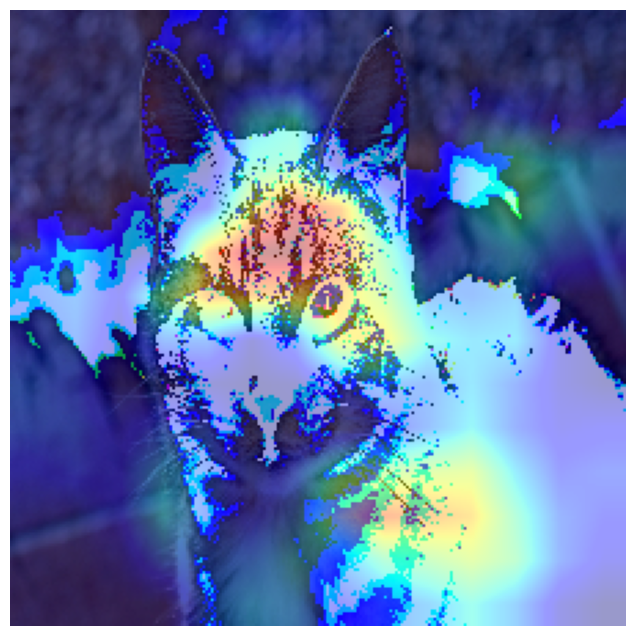

In [91]:
# resize the heatmap to match the image dimension
from PIL import Image
import matplotlib.pyplot as plt
resized_heatmap = tf.image.resize(
        heatmap[..., np.newaxis],
        size=image_array.shape[:2]
    )
resized_heatmap = tf.squeeze(resized_heatmap).numpy()

plt.figure(figsize=(8, 8))

# Original image
plt.imshow(
    image_array.astype(np.uint16),
)

# Heatmap on top
plt.imshow(
    resized_heatmap,
    cmap="jet",
    alpha=0.4
)

plt.axis("off")
plt.show()